/Users/aranyabasu/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x15007f0d0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Model Performance (Lower RMSE = Better)

EWM RMSE : 25.7459
RF  RMSE : 1.5004
XGB RMSE : 0.0898
DL  RMSE : 1.2627

Best weighting model: XGB


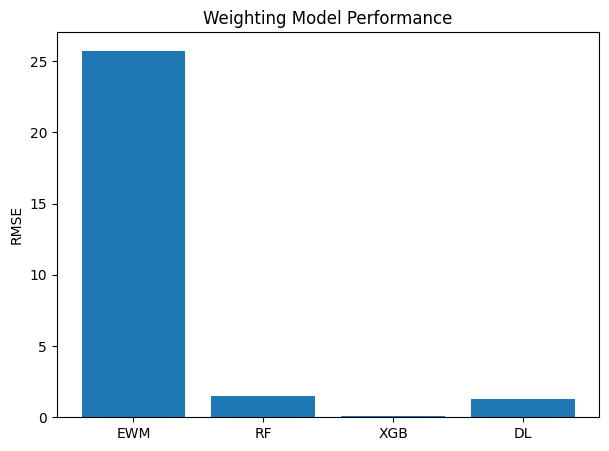

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


# =========================
# Load Data
# =========================

def load_data(file_path):

    df = pd.read_csv(file_path)

    df.columns = df.columns.str.strip().str.replace('\ufeff','')

    df['name'] = df['name'].astype(str).str.strip()
    df['team_name'] = df['team_name'].astype(str).str.strip()
    df['position_short'] = df['position_short'].astype(str).str.upper().str.strip()

    df['position_short'] = df['position_short'].replace({
        'F':'FW','FWD':'FW','ST':'FW',
        'M':'MF','MID':'MF',
        'D':'DF','DEF':'DF',
        'GK':'GK','G':'GK'
    })

    df.fillna(0,inplace=True)

    return df


# =========================
# Weight Methods
# =========================

def compute_ewm_weights(X):

    data = X.astype(float).values

    col_sums = np.maximum(data.sum(axis=0),1e-12)

    P = data/col_sums

    n = P.shape[0]

    k = 1/np.log(n)

    entropy = -k*np.nansum(P*np.log(P+1e-12),axis=0)

    divergence = 1-entropy

    weights = divergence/divergence.sum()

    return weights


def compute_rf_weights(X):

    X_numeric = X.astype(float)
    y = X_numeric.sum(axis=1)

    rf = RandomForestRegressor(n_estimators=300,random_state=42)

    rf.fit(X_numeric,y)

    predictions = rf.predict(X_numeric)

    rmse = np.sqrt(mean_squared_error(y,predictions))

    weights = rf.feature_importances_
    weights = weights/weights.sum()

    return weights, rmse


def compute_xgb_weights(X):

    X_numeric = X.astype(float)
    y = X_numeric.sum(axis=1)

    model = XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        objective='reg:squarederror'
    )

    model.fit(X_numeric,y)

    predictions = model.predict(X_numeric)

    rmse = np.sqrt(mean_squared_error(y,predictions))

    weights = model.feature_importances_
    weights = weights/weights.sum()

    return weights, rmse


def compute_dl_weights(X):

    X_numeric = X.astype(float).values

    y = X_numeric.sum(axis=1)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_numeric)

    model = Sequential([
        Dense(32,activation='relu',input_shape=(X_scaled.shape[1],)),
        Dense(16,activation='relu'),
        Dense(8,activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse'
    )

    model.fit(
        X_scaled,
        y,
        epochs=80,
        batch_size=16,
        verbose=0
    )

    predictions = model.predict(X_scaled).flatten()

    rmse = np.sqrt(mean_squared_error(y,predictions))

    weights = np.abs(model.layers[0].get_weights()[0]).mean(axis=1)

    weights = weights/weights.sum()

    return weights, rmse


# =========================
# Radar Plot
# =========================

def plot_radar(player1_stats,player2_stats,stats_labels,player1,player2):

    angles=[n/float(len(stats_labels))*2*pi for n in range(len(stats_labels))]
    angles+=angles[:1]

    player1_stats=np.append(player1_stats,player1_stats[0])
    player2_stats=np.append(player2_stats,player2_stats[0])

    fig,ax=plt.subplots(figsize=(10,8),subplot_kw=dict(polar=True))

    ax.plot(angles,player1_stats,label=player1)
    ax.fill(angles,player1_stats,alpha=0.25)

    ax.plot(angles,player2_stats,label=player2,color='orange')
    ax.fill(angles,player2_stats,alpha=0.25,color='orange')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(stats_labels)

    ax.set_ylim(0,1)

    plt.title(f"{player1} vs {player2}")
    plt.legend()

    plt.show()


# =========================
# Main
# =========================

def main():

    file_path="/Users/aranyabasu/Desktop/dataanalysislearning/project_final/source_code/final_year_project_dataset.csv"

    df=load_data(file_path)

    position=input("Enter position (FW, MF, DF, GK): ").upper()

    if position=="FW":

        stats=[
            'events.goals','events.assists',
            'events.shots_on_target','events.key_passes',
            'touches.successful_passes'
        ]

    elif position=="MF":

        stats=[
            'events.assists','events.key_passes',
            'events.chances_created','touches.successful_passes',
            'touches.interceptions'
        ]

    elif position=="DF":

        stats=[
            'touches.tackles','touches.blocks',
            'touches.interceptions','touches.clearance'
        ]

    else:

        stats=[
            'goaltenders.saves','goaltenders.shots_faced',
            'events.cleansheet'
        ]


    position_df=df[df['position_short']==position].copy()

    X=position_df[stats].astype(float)

    y=X.sum(axis=1)


    # ======================
    # Compute weights
    # ======================

    weights_ewm=compute_ewm_weights(X)
    score_ewm=X.dot(weights_ewm)

    weights_rf,rmse_rf=compute_rf_weights(X)
    score_rf=X.dot(weights_rf)

    weights_xgb,rmse_xgb=compute_xgb_weights(X)
    score_xgb=X.dot(weights_xgb)

    weights_dl,rmse_dl=compute_dl_weights(X)
    score_dl=X.dot(weights_dl)


    # ======================
    # Evaluate Models
    # ======================

    rmse_ewm=np.sqrt(mean_squared_error(y,score_ewm))

    print("\nModel Performance (Lower RMSE = Better)\n")

    print(f"EWM RMSE : {rmse_ewm:.4f}")
    print(f"RF  RMSE : {rmse_rf:.4f}")
    print(f"XGB RMSE : {rmse_xgb:.4f}")
    print(f"DL  RMSE : {rmse_dl:.4f}")


    rmse_scores={
        "EWM":rmse_ewm,
        "RF":rmse_rf,
        "XGB":rmse_xgb,
        "DL":rmse_dl
    }

    best_model=min(rmse_scores,key=rmse_scores.get)

    print("\nBest weighting model:",best_model)


    # ======================
    # Visualization
    # ======================

    plt.figure(figsize=(7,5))

    models=list(rmse_scores.keys())
    values=list(rmse_scores.values())

    plt.bar(models,values)

    plt.ylabel("RMSE")
    plt.title("Weighting Model Performance")

    plt.show()


if __name__=="__main__":
    main()

Why XGBoost Performs Better Than Deep Learning in This Project

In the model comparison, XGBoost performed better than the Deep Learning (DL) model based on the evaluation metric (RMSE). This result is expected for many tabular datasets like football player statistics.

1. Tree-Based Models Work Better on Tabular Data

XGBoost is specifically designed for structured tabular data, where features are columns such as goals, assists, tackles, and passes. Decision-tree–based algorithms can easily split the data based on feature values and discover patterns without needing extremely large datasets.

Deep learning models generally perform best on high-dimensional data such as images, audio, or text. When the dataset mainly consists of numerical columns with limited features, tree-based models like XGBoost often outperform neural networks.

2. Dataset Size Is Relatively Small

Deep learning models require large amounts of data to learn meaningful patterns. In many sports analytics datasets, the number of players and observations is relatively small compared to datasets used in deep learning applications.

Because of this:

The neural network may not learn stable patterns

It may underfit or overfit easily

XGBoost, however, can perform very well even with smaller datasets.

3. Boosting Improves Error Correction

XGBoost uses a gradient boosting approach, meaning trees are trained sequentially. Each new tree focuses on correcting the errors made by the previous trees. This iterative improvement allows the model to capture subtle relationships between player statistics.

A basic neural network does not inherently focus on correcting specific errors in the same way boosting algorithms do.

4. Strong Regularization and Optimization

XGBoost includes built-in mechanisms that make it highly efficient and stable:

Regularization (L1 and L2) to prevent overfitting

Learning rate control for gradual learning

Tree pruning to reduce unnecessary complexity

These optimizations allow XGBoost to produce highly accurate models for tabular data problems.

5. Neural Networks Require More Hyperparameter Tuning

Deep learning models are sensitive to choices such as:

number of layers

number of neurons

learning rate

batch size

epochs

If these parameters are not carefully tuned, the neural network may not perform optimally. XGBoost generally requires less tuning to achieve strong performance.

Conclusion

XGBoost performs better than the deep learning model in this project because it is better suited for structured tabular datasets, requires less data, and uses gradient boosting to iteratively improve predictions. These characteristics allow it to model the relationships between player statistics more effectively than the neural network used in this analysis.

In [2]:
pip install ultralytics opencv-python numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.2 MB 427 kB/s eta 0:00:01
     |████████████████████████████████| 46.2 MB 4.1 MB/s eta 0:00:01
     |████████████████████████████████| 73.6 MB 329 kB/s eta 0:00:014     |██████████████████████▍         | 51.5 MB 1.5 MB/s eta 0:00:15
     |████████████████████████████████| 802 kB 1.6 MB/s eta 0:00:01
     |████████████████████████████████| 1.9 MB 1.4 MB/s eta 0:00:01
     |████████████████████████████████| 5.3 MB 2.1 MB/s eta 0:00:01
     |████████████████████████████████| 7.8 MB 3.1 MB/s eta 0:00:01
     |████████████████████████████████| 249 kB 2.1 MB/s eta 0:00:01
     |████████████████████████████████| 39.3 MB 3.7 MB/s eta 0:00:01
     |████████████████████████████████| 6.3 MB 2.8 MB/s eta 0:00:01
     |████████████████████████████████| 1.6 MB 1.8 MB/s eta 0:00:01
     |████████████████████████████████| 200 kB 2.5 MB/s eta 0:00:01
     |████████████████████████████

In [ ]:
from ultralytics import YOLO
import cv2

# Load YOLO model
model = YOLO("yolov8n.pt")

# Load video
cap = cv2.VideoCapture("football.mp4")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Run detection
    results = model(frame)

    # Draw results
    annotated_frame = results[0].plot()

    cv2.imshow("Football Analysis", annotated_frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()